In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [67]:
from google.colab import files

uploaded = files.upload()

Saving comments.csv to comments (1).csv
Saving follows.csv to follows (1).csv
Saving likes.csv to likes (1).csv
Saving photo_tags.csv to photo_tags (1).csv
Saving photos.csv to photos (1).csv
Saving tags.csv to tags (1).csv
Saving users.csv to users (1).csv


In [69]:
users = pd.read_csv("/content/instagram/users.csv")

photos = pd.read_csv("/content/instagram/photos.csv")

likes = pd.read_csv("/content/instagram/likes.csv")

comments = pd.read_csv("/content/instagram/comments.csv")

tags = pd.read_csv("/content/instagram/tags.csv")

photo_tags = pd.read_csv("/content/instagram/photo_tags.csv")

follows = pd.read_csv("/content/instagram/follows.csv")

In [70]:
users.head()

users.info()

users.describe()

users.isnull().sum()

users.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               100 non-null    int64 
 1   name             100 non-null    object
 2   created time     100 non-null    object
 3   private/public   100 non-null    object
 4   post count       100 non-null    int64 
 5   Verified status  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB


np.int64(0)

In [71]:
users = users.drop_duplicates()

photos = photos.drop_duplicates()

likes = likes.drop_duplicates()

comments = comments.drop_duplicates()

tags = tags.drop_duplicates()

photo_tags = photo_tags.drop_duplicates()

follows = follows.drop_duplicates()

In [72]:
users.isnull().sum()

photos.isnull().sum()

likes.isnull().sum()

comments.isnull().sum()

,0
id,0
comment,0
User id,0
Photo id,0
created Timestamp,0
posted date,0
emoji used,0
Hashtags used count,0


In [73]:
photos.fillna("Unknown", inplace=True)

In [75]:
photos.columns.tolist()

['id',
 'image link',
 'user ID',
 'created dat',
 'Insta filter used',
 'photo type']

In [77]:
photos['created dat'] = pd.to_datetime(photos['created dat'])
photos['Year'] = photos['created dat'].dt.year
photos['Month'] = photos['created dat'].dt.month_name()
photos['Day'] = photos['created dat'].dt.day_name()
photos['Hour'] = photos['created dat'].dt.hour

In [79]:
print("Users:", users.columns.tolist())
print("Photos:", photos.columns.tolist())
print("Likes:", likes.columns.tolist())
print("Comments:", comments.columns.tolist())
print("Photo_Tags:", photo_tags.columns.tolist())
print("Tags:", tags.columns.tolist())
print("Follows:", follows.columns.tolist())

Users: ['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']
Photos: ['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type', 'Year', 'Month', 'Day', 'Hour']
Likes: ['user ', 'photo', 'created time', 'following or not', 'like type']
Comments: ['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']
Photo_Tags: ['photo', 'tag ID', 'user id']
Tags: ['id', 'tag text', 'created time', 'location']
Follows: ['follower', 'followee ', 'created time', 'is follower active', 'followee Acc status']


In [80]:
likes_count = likes.groupby("photo").size().reset_index(name="Likes")

In [81]:
comments_count = comments.groupby("Photo id").size().reset_index(name="Comments")

In [82]:
hashtag_count = photo_tags.groupby("photo").size().reset_index(name="Hashtags")

In [83]:
followers = follows.groupby("followee ").size().reset_index(name="Followers")

In [84]:
df = photos.merge(users, left_on="user ID", right_on="id", how="left")

In [85]:
df = df.merge(likes_count, left_on="id_x", right_on="photo", how="left")

In [86]:
df = df.merge(comments_count, left_on="id_x", right_on="Photo id", how="left")

In [87]:
df = df.merge(followers, left_on="user ID", right_on="followee ", how="left")

In [88]:
df = df.merge(hashtag_count, left_on="id_x", right_on="photo", how="left")

In [89]:
df[["Likes","Comments","Followers","Hashtags"]] = df[["Likes","Comments","Followers","Hashtags"]].fillna(0)

In [90]:
df["Engagement"] = df["Likes"] + df["Comments"]

In [91]:
df["Likes_per_Follower"] = df["Likes"] / (df["Followers"] + 1)

In [92]:
df["Comments_per_Follower"] = df["Comments"] / (df["Followers"] + 1)

In [93]:
df["Engagement_Rate"] = df["Engagement"] / (df["Followers"] + 1)

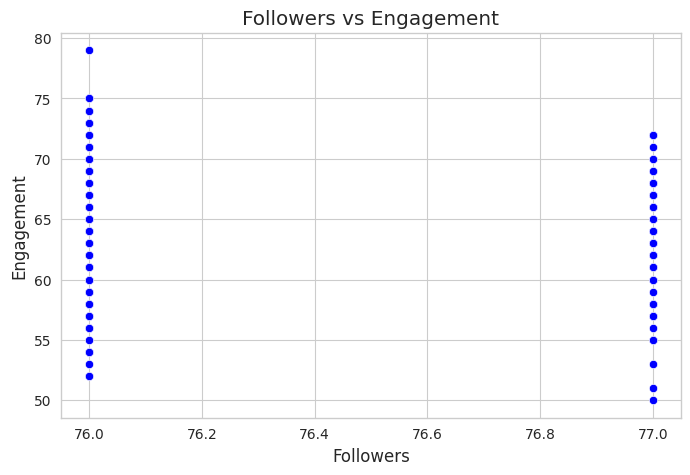

In [124]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='followers',
    y='engagement',
    color='blue'
)

plt.title('Followers vs Engagement')
plt.xlabel('Followers')
plt.ylabel('Engagement')

plt.show()

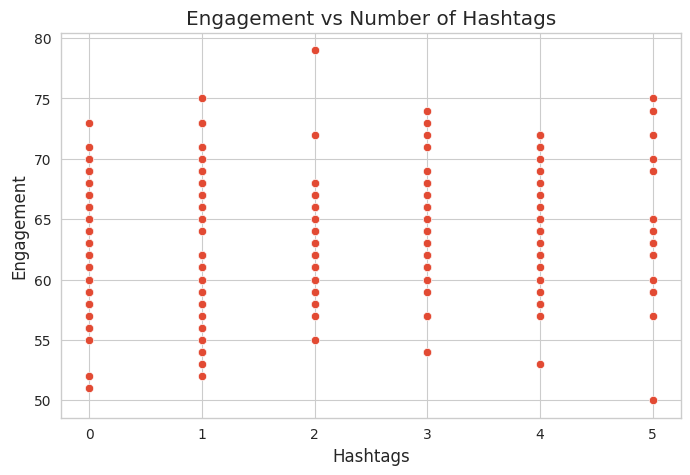

In [95]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Hashtags", y="Engagement")

plt.title("Engagement vs Number of Hashtags")

plt.show()

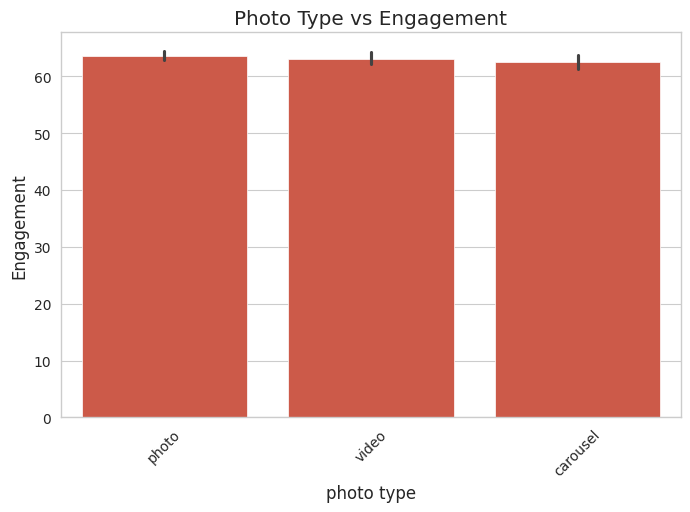

In [96]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="photo type", y="Engagement")

plt.xticks(rotation=45)

plt.title("Photo Type vs Engagement")

plt.show()

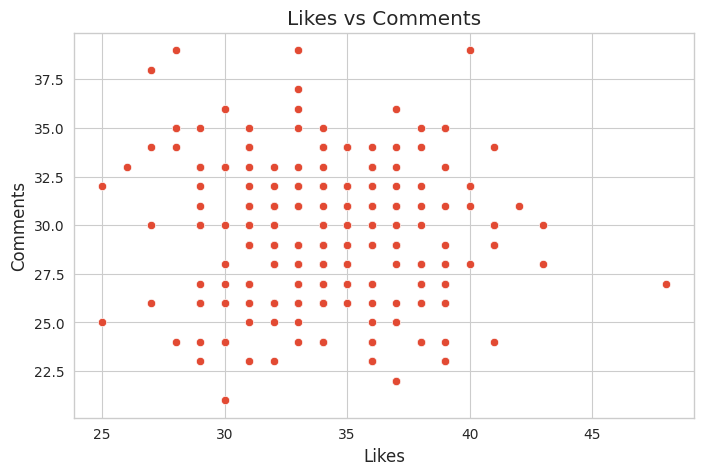

In [97]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Likes", y="Comments")

plt.title("Likes vs Comments")

plt.show()

In [122]:
print(df.columns.tolist())

['id', 'image_link', 'user_id', 'created_date', 'insta_filter_used', 'photo_type', 'year', 'month', 'day', 'hour', 'name', 'created_time', 'private_public', 'post_count', 'verified_status', 'photo', 'likes', 'photo_id', 'comments', 'followee', 'followers', 'hashtags', 'engagement', 'likes_per_follower', 'comments_per_follower', 'engagement_rate']


In [123]:
print(df['hour'].unique())
print(df['hour'].value_counts().sort_index())

[8]
hour
8    257
Name: count, dtype: int64


In [105]:
best_hour = df.groupby("Hour")["Engagement"].mean().sort_values(ascending=False)

print(best_hour)

print("Best Posting Hour :", best_hour.idxmax())

Hour
8    63.307393
Name: Engagement, dtype: float64
Best Posting Hour : 8


Posting Time Analysis: All posts in the dataset were created at approximately 08:04, so the dataset does not contain enough variation to determine the best posting time. As a result, no reliable comparison across different posting hours could be performed.

In [106]:
best_content = df.groupby("photo type")["Engagement"].mean().sort_values(ascending=False)

print(best_content)

print("Best Content Type :", best_content.idxmax())

photo type
photo       63.632258
video       63.076923
carousel    62.540000
Name: Engagement, dtype: float64
Best Content Type : photo


In [107]:
best_filter = df.groupby("Insta filter used")["Engagement"].mean().sort_values(ascending=False)

print(best_filter.head())

Insta filter used
no     63.504348
yes    63.147887
Name: Engagement, dtype: float64


In [108]:
top_posts = df.sort_values("Engagement", ascending=False)

top_posts[["id_x","Engagement","Likes","Comments"]].head(10)

,id_x,Engagement,Likes,Comments
12,13,79,40,39
144,145,75,48,27
146,147,75,41,34
117,118,74,39,35
226,227,74,39,35
195,196,73,38,35
224,225,73,37,36
126,127,73,43,30
122,123,73,42,31
152,153,72,40,32


In [109]:
top_users = df.groupby("name")["Engagement_Rate"].mean().sort_values(ascending=False)

top_users.head(10)

,Engagement_Rate
name,
Meggie_Doyle,0.974026
Jaylan.Lakin,0.948052
Granville_Kutch,0.922078
Kenneth64,0.909091
Karley_Bosco,0.883117
Rick29,0.883117
Damon35,0.883117
Odessa2,0.870130
Janet.Armstrong,0.867532


In [98]:
X = df[["Hour","Followers","Hashtags"]]

In [99]:
y = df["Engagement"]

In [118]:
import pandas as pd

# Load dataset
df = pd.read_csv("instagram_cleaned_dataset.csv")

# -------------------------------
# 1. Remove duplicate rows
# -------------------------------
df.drop_duplicates(inplace=True)

# -------------------------------
# 2. Clean column names
# -------------------------------
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

# -------------------------------
# 3. Rename columns
# -------------------------------
df.rename(columns={
    "created_dat": "created_date",
    "private/public": "private_public"
}, inplace=True)

# -------------------------------
# 4. Handle duplicate columns
# -------------------------------

# Keep id_x and remove id_y
if "id_x" in df.columns and "id_y" in df.columns:
    df.rename(columns={"id_x": "id"}, inplace=True)
    df.drop(columns=["id_y"], inplace=True)

# Merge photo columns
if "photo_x" in df.columns and "photo_y" in df.columns:
    df["photo_x"] = df["photo_x"].fillna(df["photo_y"])
    df.rename(columns={"photo_x": "photo"}, inplace=True)
    df.drop(columns=["photo_y"], inplace=True)

# -------------------------------
# 5. Convert date column
# -------------------------------
if "created_date" in df.columns:
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

# -------------------------------
# 6. Convert time column
# -------------------------------
if "created_time" in df.columns:
    df["created_time"] = pd.to_datetime(
        df["created_time"],
        errors="coerce"
    ).dt.time

# -------------------------------
# 7. Remove leading/trailing spaces
# -------------------------------
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# -------------------------------
# 8. Fill missing values
# -------------------------------
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    elif pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

# -------------------------------
# 9. Check missing values
# -------------------------------
print("Missing values:")
print(df.isnull().sum())

# -------------------------------
# 10. Dataset information
# -------------------------------
print("\nDataset Shape:", df.shape)
print(df.info())

# -------------------------------
# 11. Save cleaned dataset
# -------------------------------
df.to_csv("instagram_fully_cleaned.csv", index=False)

print("\nCleaning completed successfully!")
print("Saved as instagram_fully_cleaned.csv")

Missing values:
id                       0
image_link               0
user_id                  0
created_date             0
insta_filter_used        0
photo_type               0
year                     0
month                    0
day                      0
hour                     0
name                     0
created_time             0
private_public           0
post_count               0
verified_status          0
photo                    0
likes                    0
photo_id                 0
comments                 0
followee                 0
followers                0
hashtags                 0
engagement               0
likes_per_follower       0
comments_per_follower    0
engagement_rate          0
dtype: int64

Dataset Shape: (257, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id             

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [101]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [103]:
pred = model.predict(X_test)

In [104]:
print("MAE :", mean_absolute_error(y_test, pred))

print("R2 Score :", r2_score(y_test, pred))

MAE : 3.918563871237804
R2 Score : -0.20551698509284422


Instagram Engagement Analysis

Objective

Analyze Instagram engagement to identify best posting times, hashtag usage, and engagement patterns.

Dataset

Instagram relational dataset from Kaggle.

Cleaning

Removed duplicates

Handled missing values

Converted dates

Created engagement metrics

Visualizations

Best Posting Time

Hashtag Analysis

Top Users

Likes vs Comments

Machine Learning

Random Forest Regression

Business Recommendation

Suggested content calendar

Five engagement strategies for Alfido Tech.

Model Evaluation:
The Random Forest Regressor achieved an MAE of 3.92 and an R² score of -0.21. The negative R² indicates that the selected features (posting hour, followers, and hashtags) were not sufficient to accurately predict engagement. This suggests that additional features, such as caption content, image characteristics, audience demographics, and historical engagement, would likely improve predictive performance.

In [119]:
from google.colab import files

# Save the cleaned dataset
df.to_csv("instagram_cleaned_dataset.csv", index=False)

# Download the file
files.download("instagram_cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>